# Data Exploration — UAV VoiceControl Benchmark

Dieses Notebook analysiert den **Google Speech Commands Datensatz**, der als Grundlage für das UAV-Sprachsteuerungsprojekt dient.  
Ziel ist es, die Datenqualität und -struktur zu verstehen, bevor mit dem Preprocessing und dem Modelltraining begonnen wird.  

**Inhalt:**
1. Imports
2. Dateianzahl pro Klasse
3. Verteilung der Oberklassen (Keywords / Unknown / Background Noise)
4. Waveform-Visualisierung
5. Dauern-Analyse
6. Sample Rate Check


## 1. Imports

In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import librosa
import numpy as np
import math

## 2. Dateianzahl pro Klasse

Für jede Unterklasse im Datensatz wird die Anzahl der `.wav`-Dateien gezählt und aufsteigend sortiert visualisiert.  
**Rot** markierte Balken sind die 10 UAV-relevanten Keywords (`forward`, `backward`, `up`, `down`, `stop`, `right`, `left`, `go`, `one`, `two`),  
**grün** markierte Balken sind alle übrigen Klassen (Unknown Words & Background Noise).


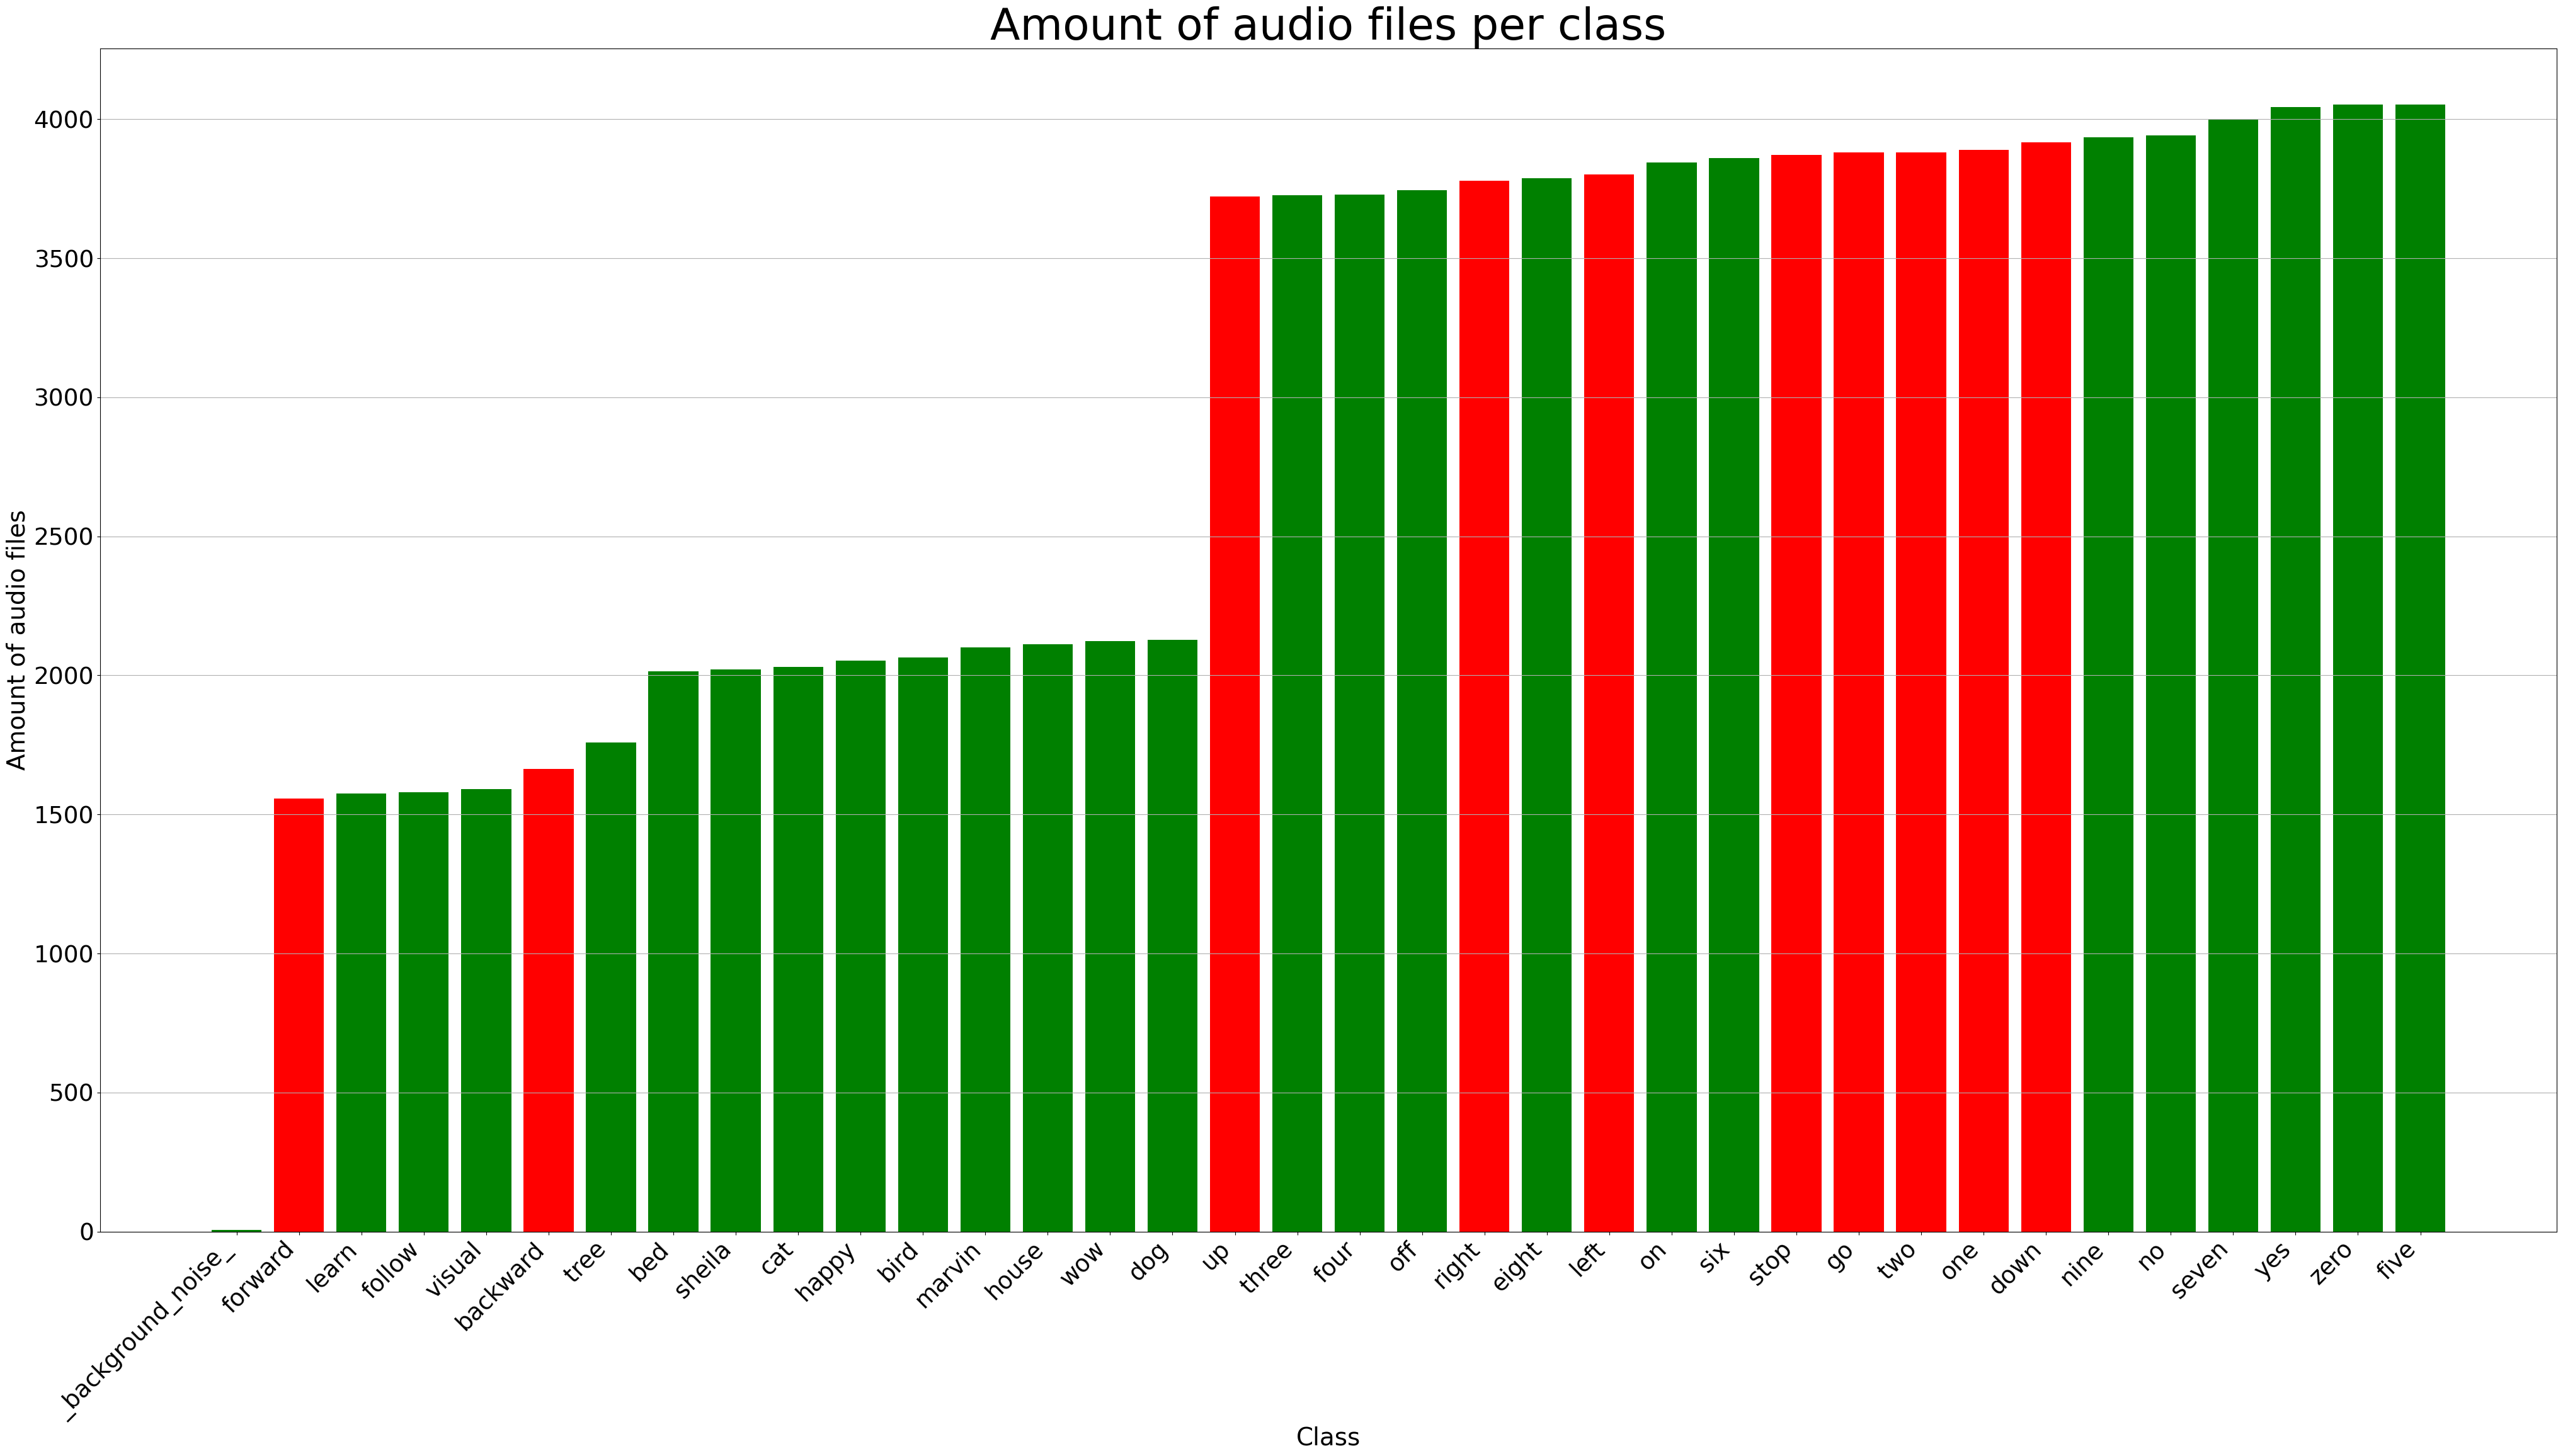

Amount of audio files per class:
_background_noise_   | 6
forward              | 1557
learn                | 1575
follow               | 1579
visual               | 1592
backward             | 1664
tree                 | 1759
bed                  | 2014
sheila               | 2022
cat                  | 2031
happy                | 2054
bird                 | 2064
marvin               | 2100
house                | 2113
wow                  | 2123
dog                  | 2128
up                   | 3723
three                | 3727
four                 | 3728
off                  | 3745
right                | 3778
eight                | 3787
left                 | 3801
on                   | 3845
six                  | 3860
stop                 | 3872
go                   | 3880
two                  | 3880
one                  | 3890
down                 | 3917
nine                 | 3934
no                   | 3941
seven                | 3998
yes                  | 4044
zero              

In [2]:
base_path = Path.cwd().parent
path_to_raw_data = os.path.join(base_path, 'data/raw/speech_command_data')


file_amount = {}

for folder in Path(path_to_raw_data).iterdir():
    if folder.is_dir():
        audio_files = list(folder.glob('*.wav'))
        count = len(audio_files)
        file_amount.update({folder.name: count})

file_amount = dict(sorted(file_amount.items(), key=lambda item: item[1]))   

colors = ['red' if (label in ['forward', 'right', 'up', 'down', 'left', 'backward', 'stop', 'go', 'one', 'two']) 
          else 'green' for label in file_amount.keys()]

plt.figure(figsize=(40,20))
plt.xticks(rotation=45, ha='right', fontsize=27)
plt.yticks(fontsize=27)
plt.grid(axis='y')
plt.tight_layout()
plt.bar(file_amount.keys(), file_amount.values(), color=colors)
plt.title('Amount of audio files per class', fontsize=50)
plt.xlabel('Class', fontsize=28)
plt.ylabel('Amount of audio files', fontsize=28)
plt.show()

print('Amount of audio files per class:')
for key, value in file_amount.items():
    print(f'{key:<20} | {value}')




In [3]:
key_words = ['forward', 'backward', 'up', 'down', 'stop', 'right', 'left', 'go', 'one', 'two']

keyword_counts = {k: v for k, v in file_amount.items() if k in key_words}

max_class = max(keyword_counts, key=keyword_counts.get)
min_class = min(keyword_counts, key=keyword_counts.get)

class_count_ratio = keyword_counts[max_class] / keyword_counts[min_class]

print(f'Größte Keyword-Klasse:  {max_class:<12} | {keyword_counts[max_class]} Dateien')
print(f'Kleinste Keyword-Klasse: {min_class:<12} | {keyword_counts[min_class]} Dateien')
print(f'Imbalance Ratio: {class_count_ratio:.2f}')

Größte Keyword-Klasse:  down         | 3917 Dateien
Kleinste Keyword-Klasse: forward      | 1557 Dateien
Imbalance Ratio: 2.52


## 3. Verteilung der Oberklassen

Die 35 Feinklassen werden in drei Oberklassen zusammengefasst:
- **Keywords** — die 10 UAV-Steuerbefehle, die das Modell erkennen soll
- **Unknown Words** — alle übrigen Sprachwörter, die als "unbekannt" klassifiziert werden sollen
- **Silence** — kurze, sehr leise Segmente aus den Background-Noise-Dateien

> **Wichtig:** `_background_noise_` ist **keine eigene Klasse** im Modell.  
> Die langen Aufnahmen erfüllen zwei Rollen:  
> 1. **Silence-Quelle** — leise Segmente (RMS < 0.01) werden als Silence-Klasse extrahiert  
> 2. **Noise-Augmentation** — lautere Segmente werden beim Training leise in andere Clips eingemischt (Volume ≈ 0.1), um das Modell robust gegen Umgebungsgeräusche zu machen  

Die Anzahl der Silence-Samples entspricht der Anzahl der extrahierbaren 1s-Segmente mit sehr niedriger Energie.

/Users/kayraozturk/Desktop/HRW/eingebettete_systeme_2/UAV_VoiceControl_Benchmark/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


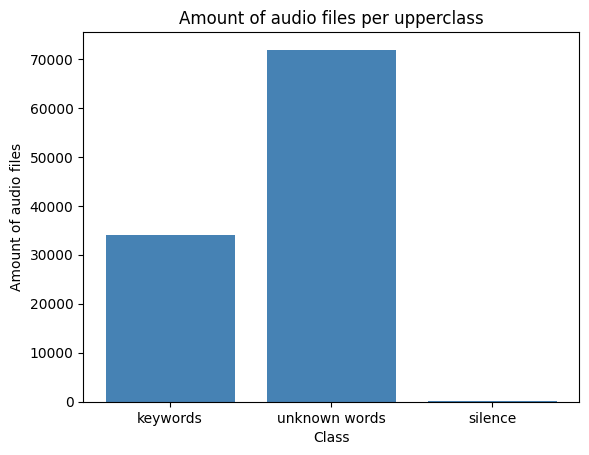

keywords            : 33962
unknown words       : 71867
silence             : 59


In [4]:
import wave

key_words = ['forward', 'backward', 'up', 'down', 'stop', 'right', 'left', 'go', 'one', 'two']
unknown_words = [
    'learn', 'follow', 'visual', 'tree', 'bed', 'sheila', 'cat', 'happy',
    'bird', 'marvin', 'house', 'wow', 'dog', 'three', 'four', 'off',
    'eight', 'on', 'six', 'nine', 'no', 'seven', 'yes', 'zero', 'five',
]

count_keywords = 0
count_unknown_words = 0

for key, value in file_amount.items():
    if key in key_words:
        count_keywords += value
    elif key in unknown_words:
        count_unknown_words += value

# Silence: 1s-Segmente aus _background_noise_ mit sehr niedriger RMS-Energie
import numpy as np
import librosa
from pathlib import Path

bg_noise_path = Path(path_to_raw_data) / '_background_noise_'
SILENCE_RMS_THRESHOLD = 0.01
SEGMENT_LENGTH = 16000  # 1s bei 16kHz

count_silence = 0
for bg_file in bg_noise_path.glob('*.wav'):
    audio, sr = librosa.load(bg_file, sr=16000)
    n_segments = len(audio) // SEGMENT_LENGTH
    for i in range(n_segments):
        segment = audio[i * SEGMENT_LENGTH:(i + 1) * SEGMENT_LENGTH]
        rms = np.sqrt(np.mean(segment ** 2))
        if rms < SILENCE_RMS_THRESHOLD:
            count_silence += 1

dict_amount_files_upperclass = {
    'keywords':      count_keywords,
    'unknown words': count_unknown_words,
    'silence':       count_silence,
}

colors = ['steelblue', 'steelblue', 'steelblue']
plt.bar(dict_amount_files_upperclass.keys(), dict_amount_files_upperclass.values(), color=colors)
plt.title('Amount of audio files per upperclass')
plt.xlabel('Class')
plt.ylabel('Amount of audio files')
plt.show()

for key, value in dict_amount_files_upperclass.items():
    print(f'{key:<20}: {value}')

In [5]:
ratio_keywords_unknown = dict_amount_files_upperclass['unknown words'] / dict_amount_files_upperclass['keywords']
ratio_keywords_silence  = dict_amount_files_upperclass['keywords'] / max(dict_amount_files_upperclass['silence'], 1)

print(f"Keywords:      {dict_amount_files_upperclass['keywords']}")
print(f"Unknown Words: {dict_amount_files_upperclass['unknown words']}")
print(f"Silence:       {dict_amount_files_upperclass['silence']}")
print()
print(f"Imbalance Ratio (Unknown / Keywords): {ratio_keywords_unknown:.2f}")
print(f"Imbalance Ratio (Keywords / Silence): {ratio_keywords_silence:.2f}")
print()
print('Hinweis: Background Noise ist keine Klasse — wird als Noise-Augmentation beim Training genutzt.')

Keywords:      33962
Unknown Words: 71867
Silence:       59

Imbalance Ratio (Unknown / Keywords): 2.12
Imbalance Ratio (Keywords / Silence): 575.63

Hinweis: Background Noise ist keine Klasse — wird als Noise-Augmentation beim Training genutzt.


## 4. Waveform-Visualisierung

Für jede Klasse wird eine Beispieldatei als Waveform (Amplitudenverlauf über die Zeit) dargestellt.  
Waveforms geben einen ersten visuellen Eindruck der akustischen Struktur — z.B. ob ein Wort kurz oder lang ist,  
ob es einen klar erkennbaren Onset hat oder ob die Aufnahme viel Hintergrundrauschen enthält.  

**Hinweis:** Das Modell arbeitet nicht direkt mit der Waveform, sondern mit Spektral-Features (z.B. Mel-Spektrogramm).  
Die Waveform ist dennoch nützlich zur Qualitätskontrolle.


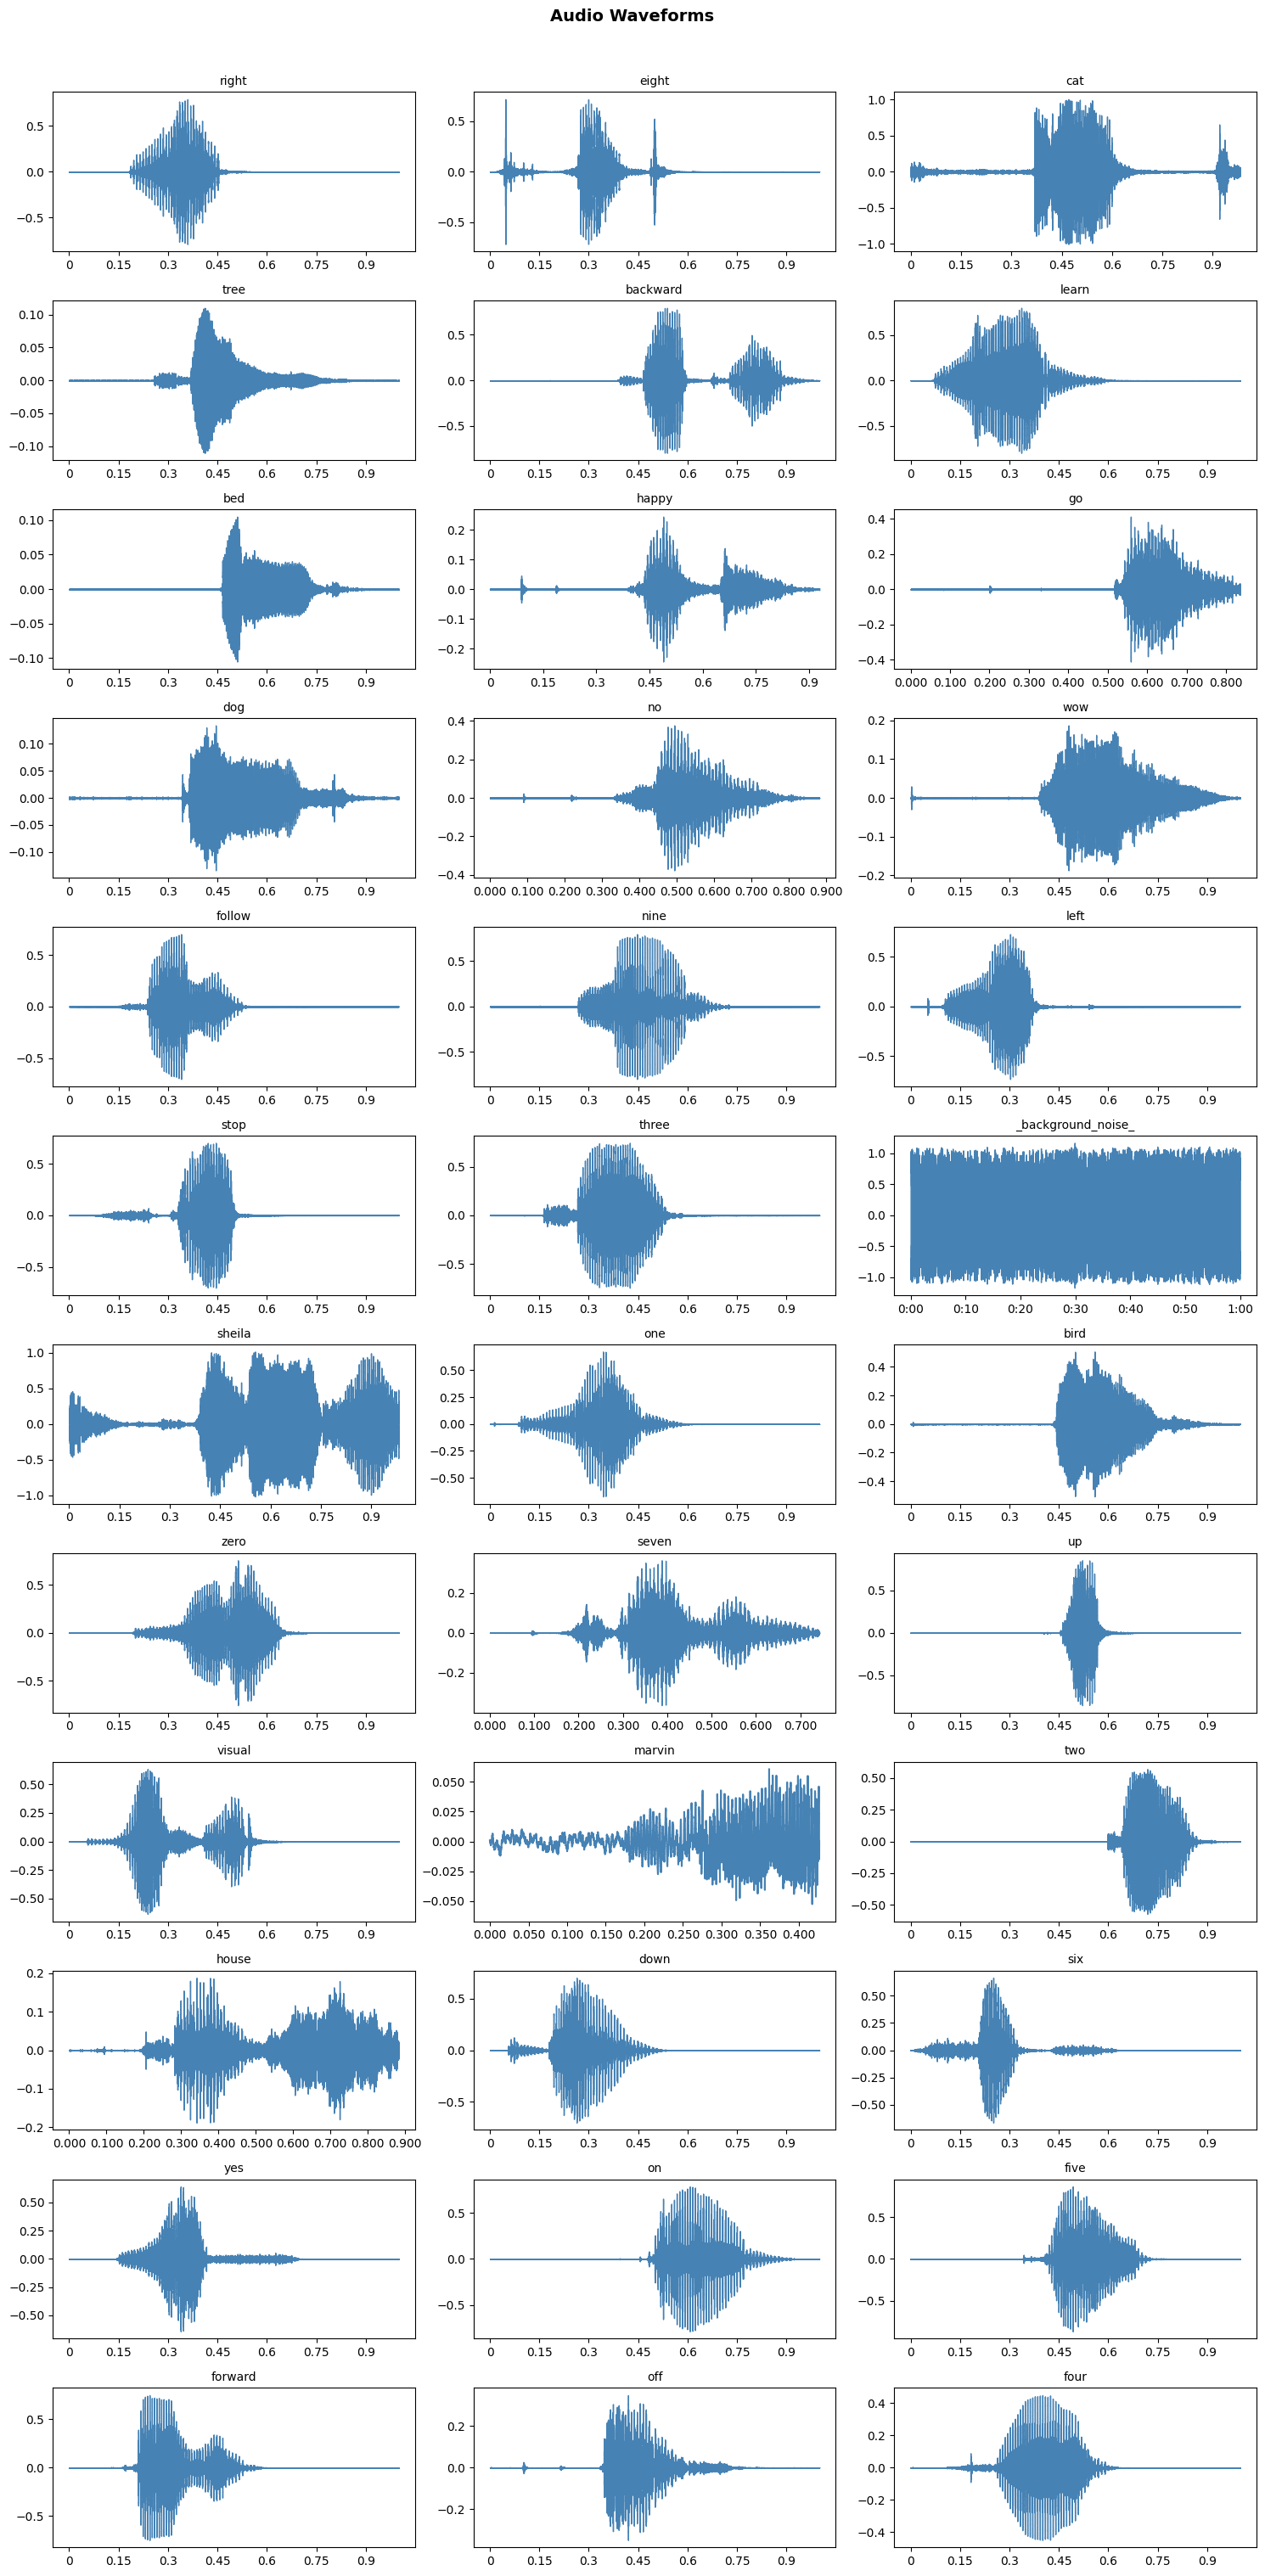

In [6]:
files = []

for folder in Path(path_to_raw_data).iterdir():
    if folder.is_dir():
        audio_files = list(folder.glob('*.wav'))
        files.append(audio_files[0])

n = len(files)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 2.5))
axes = axes.flatten()  # 2D-Array → 1D für einfaches Iterieren

for i, file in enumerate(files):
    waveform, sample_rate = librosa.load(file)
    librosa.display.waveshow(waveform, sr=sample_rate, color='steelblue', ax=axes[i])
    axes[i].set_title(file.parent.name, fontsize=10)  # Ordnername als Titel
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# Übrige leere Subplots ausblenden
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Audio Waveforms", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5. Dauern-Analyse

Die Dauer jeder Audiodatei wird mit `librosa` gemessen (exkl. `_background_noise_`).  
Der Google Speech Commands Datensatz ist so konzipiert, dass alle Clips **genau 1 Sekunde** lang sein sollen.  
In der Praxis gibt es jedoch kürzere Aufnahmen — diese müssen beim Preprocessing auf 1 Sekunde **gepaddet** werden,  
um eine einheitliche Eingabegröße für das Modell zu gewährleisten.


In [7]:
durations = []


for folder in Path(path_to_raw_data).iterdir():
    if folder.is_dir() and folder.name != '_background_noise_':
        audio_files = list(folder.glob('*.wav'))
        for file in audio_files:
            audio, sr = librosa.load(file, sr=None)
            duration = librosa.get_duration(y=audio, sr=sr)
            durations.append(duration)
            

In [8]:
for d in durations:
    if d != 1.0:
        print('Found audio file with duration not 1 secound.')
        break

max_duration = max(durations)
min_duration = min(durations)

print(f'Maximun duration: {max_duration}')
print(f'Minimum duration: {min_duration}')
print('Note: _brackground_noise_ excluded')

Found audio file with duration not 1 secound.
Maximun duration: 1.0
Minimum duration: 0.2133125
Note: _brackground_noise_ excluded


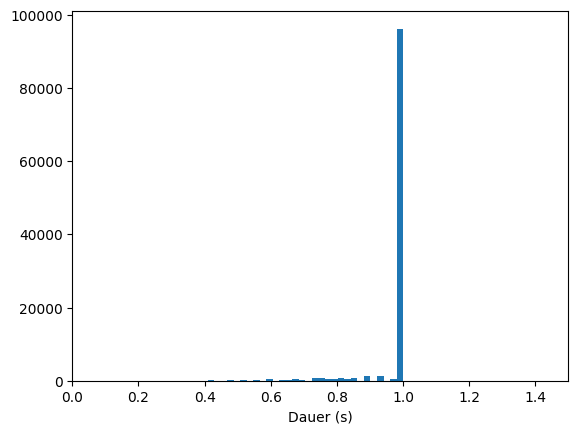

In [9]:
plt.hist(durations, bins=40)
plt.xlabel("Dauer (s)")
plt.xlim(0, 1.5)
plt.show()

## 5.1 Analyse — Background Noise Dateien

Die `_background_noise_`-Dateien sind lange Umgebungsgeräusch-Aufnahmen (~60s).  
Sie erfüllen im Projekt **zwei Rollen** — keine davon ist eine eigene Modell-Klasse:

**Rolle 1 — Silence-Klasse:**  
Segmente mit sehr niedriger RMS-Energie (< 0.01) werden als 1s-Clips extrahiert und bilden die Silence-Klasse.  
Das Modell lernt damit: *"Hier spricht niemand."*

**Rolle 2 — Noise-Augmentation:**  
Lautere Segmente werden beim Training leise (Volume ≈ 0.1) in andere Audio-Clips eingemischt.  
Das macht das Modell robust gegen Motorenlärm und Umgebungsgeräusche — besonders wichtig für den UAV-Einsatz.

Analysiert wird hier:
- Gesamtdauer und maximale 1s-Segmente pro Datei
- RMS-Energie pro Segment → Anteil Silence vs. Noise-Augmentation

In [10]:
import numpy as np

bg_noise_path = Path(path_to_raw_data) / '_background_noise_'
bg_files = list(bg_noise_path.glob('*.wav'))
SILENCE_RMS_THRESHOLD = 0.01
SEGMENT_LENGTH = 16000

print(f'Anzahl Background-Noise-Dateien: {len(bg_files)}\n')
print(f'{"Dateiname":<30} | {"SR":>8} | {"Dauer (s)":>10} | {"1s-Segmente":>12} | {"davon Silence":>14} | {"davon Noise-Aug":>16}')
print('-' * 100)

total_segments = 0
total_silence  = 0
total_noise    = 0

for file in sorted(bg_files):
    audio, sr = librosa.load(file, sr=16000)
    duration   = librosa.get_duration(y=audio, sr=sr)
    n_segments = int(duration)
    n_silence  = 0
    n_noise    = 0
    for i in range(n_segments):
        seg = audio[i * SEGMENT_LENGTH:(i + 1) * SEGMENT_LENGTH]
        rms = np.sqrt(np.mean(seg ** 2))
        if rms < SILENCE_RMS_THRESHOLD:
            n_silence += 1
        else:
            n_noise += 1
    total_segments += n_segments
    total_silence  += n_silence
    total_noise    += n_noise
    print(f'{file.name:<30} | {sr:>8} Hz | {duration:>10.1f} | {n_segments:>12} | {n_silence:>14} | {n_noise:>16}')

print('-' * 100)
print(f'{"GESAMT":<30} | {"":>9} | {"":>10} | {total_segments:>12} | {total_silence:>14} | {total_noise:>16}')
print()
print(f'Silence-Segmente (RMS < {SILENCE_RMS_THRESHOLD}): {total_silence}')
print(f'Noise-Aug-Segmente (RMS ≥ {SILENCE_RMS_THRESHOLD}): {total_noise}')

Anzahl Background-Noise-Dateien: 6

Dateiname                      |       SR |  Dauer (s) |  1s-Segmente |  davon Silence |  davon Noise-Aug
----------------------------------------------------------------------------------------------------
doing_the_dishes.wav           |    16000 Hz |       95.2 |           95 |              0 |               95
dude_miaowing.wav              |    16000 Hz |       61.8 |           61 |             59 |                2
exercise_bike.wav              |    16000 Hz |       61.3 |           61 |              0 |               61
pink_noise.wav                 |    16000 Hz |       60.0 |           60 |              0 |               60
running_tap.wav                |    16000 Hz |       61.2 |           61 |              0 |               61
white_noise.wav                |    16000 Hz |       60.0 |           60 |              0 |               60
----------------------------------------------------------------------------------------------------
GE

## 6. Sample Rate Check

Überprüfung ob alle `.wav`-Dateien dieselbe Sample Rate haben.  
Ein Mix unterschiedlicher Sample Rates würde das Preprocessing und Training negativ beeinflussen.  
Die Header-Informationen werden mit dem `wave`-Modul ausgelesen — **kein vollständiges Laden der Audiodaten**, daher sehr effizient.


In [11]:
import wave
from collections import Counter

sample_rates = Counter()
errors = []

for folder in Path(path_to_raw_data).iterdir():
    if folder.is_dir():
        for file in folder.glob('*.wav'):
            try:
                with wave.open(str(file), 'r') as wf:
                    sample_rates[wf.getframerate()] += 1
            except Exception as e:
                errors.append((str(file), str(e)))

print('=== Sample Rate Distribution ===')
for sr, count in sorted(sample_rates.items()):
    print(f'  {sr} Hz : {count} Dateien')

print(f'\nGesamt geprüft: {sum(sample_rates.values())} Dateien')

if len(sample_rates) == 1:
    print(f'Alle Dateien haben dieselbe Sample Rate: {list(sample_rates.keys())[0]} Hz')
else:
    print(f'Unterschiedliche Sample Rates gefunden!')

if errors:
    print(f'\n  Fehler bei {len(errors)} Dateien:')
    for p, e in errors[:10]:
        print(f'  {p}: {e}')
else:
    print('Keine Fehler aufgetreten.')


=== Sample Rate Distribution ===
  16000 Hz : 105835 Dateien

Gesamt geprüft: 105835 Dateien
Alle Dateien haben dieselbe Sample Rate: 16000 Hz
Keine Fehler aufgetreten.


## 7. Mel-Spektrogramm — Visualisierung

Das Mel-Spektrogramm ist die **zentrale Feature-Repräsentation** für Sprachverarbeitung.  
Statt der rohen Wellenform bekommt das Modell ein 2D-Bild: **Zeit** auf der x-Achse, **Mel-Frequenz** auf der y-Achse, **Energie in dB** als Farbe.  
Die Mel-Skala orientiert sich an der menschlichen Wahrnehmung — tiefe Frequenzen werden feiner aufgelöst als hohe.  

Hier wird für jedes der **10 UAV-Keywords** ein Beispiel-Spektrogramm geplottet,  
um zu prüfen ob die Klassen akustisch unterscheidbar sind.


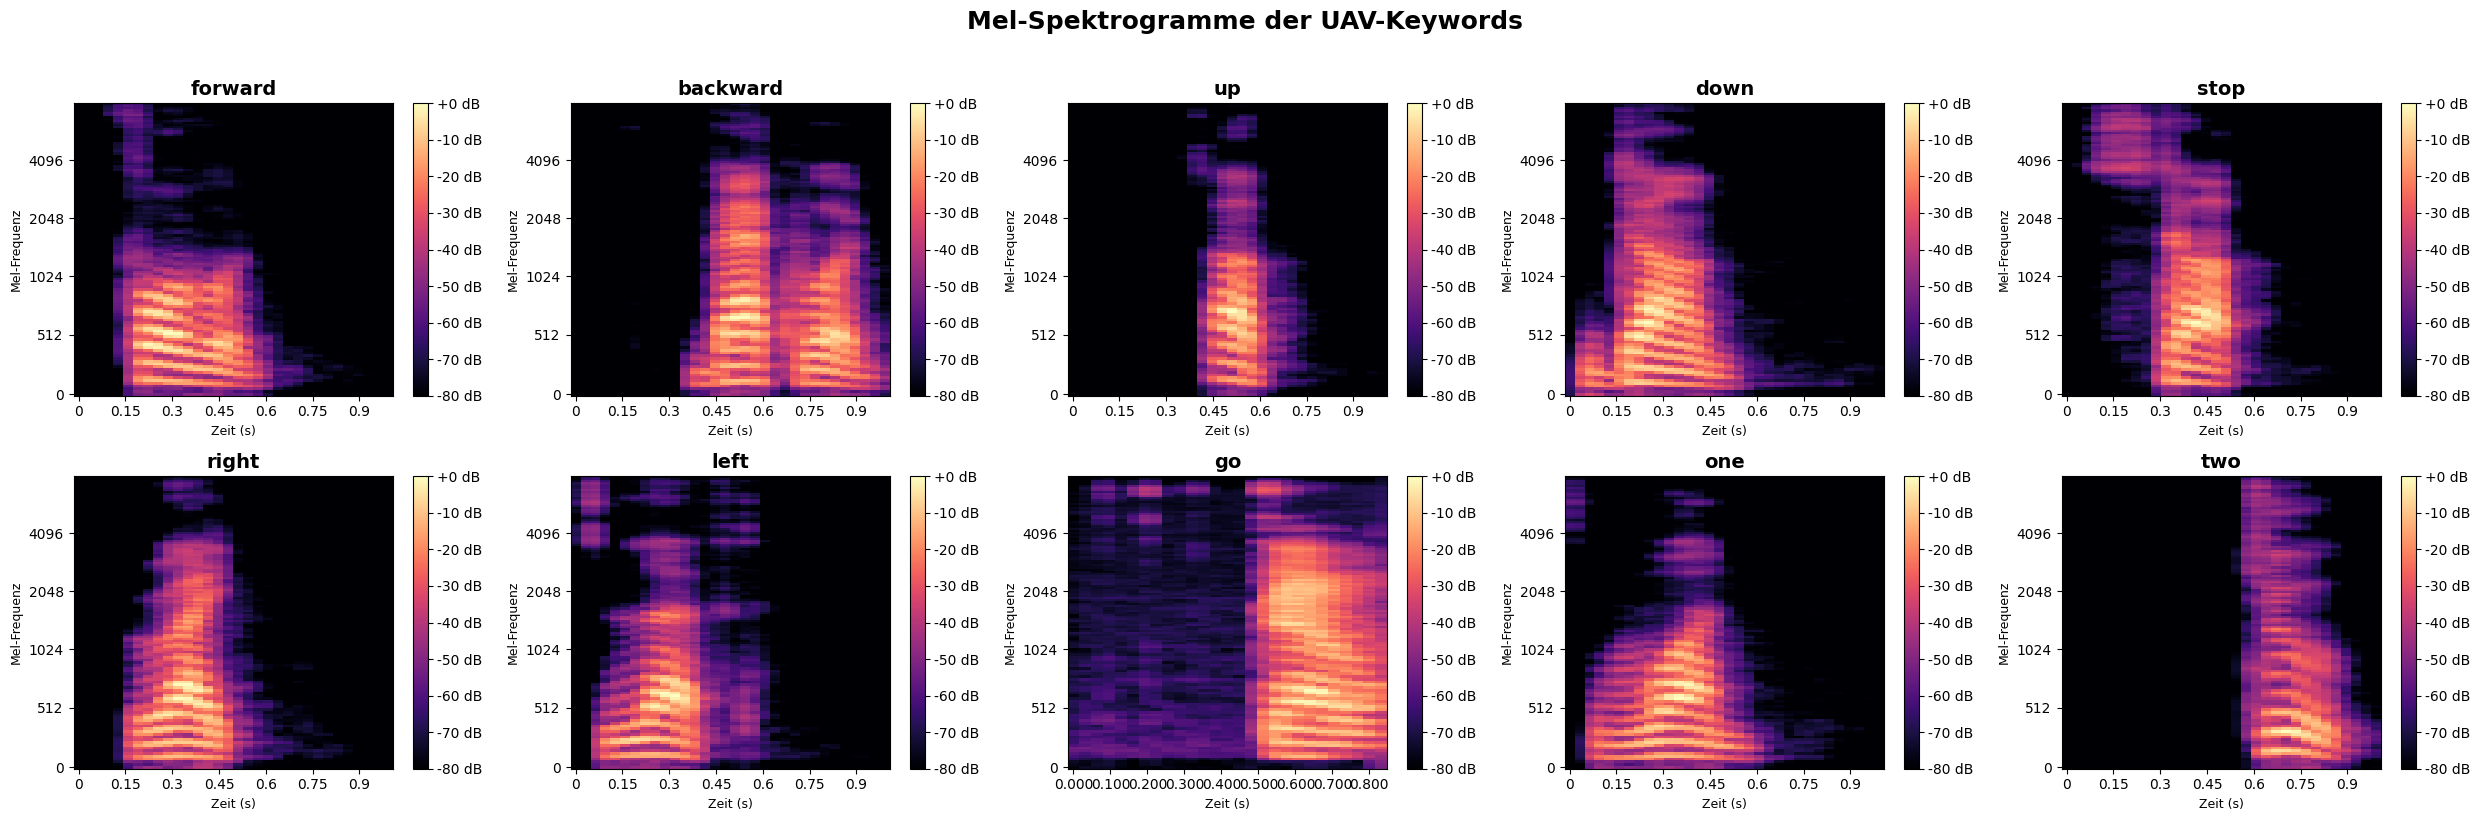

In [12]:
key_words = ['forward', 'backward', 'up', 'down', 'stop', 'right', 'left', 'go', 'one', 'two']

cols = 5
rows = 2
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()

for i, keyword in enumerate(key_words):
    keyword_path = Path(path_to_raw_data) / keyword
    example_file = list(keyword_path.glob('*.wav'))[0]

    audio, sr = librosa.load(example_file, sr=None)
    mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
    log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)

    img = librosa.display.specshow(log_mel_spec, x_axis='time', y_axis='mel', sr=sr, ax=axes[i])
    axes[i].set_title(keyword, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Zeit (s)', fontsize=9)
    axes[i].set_ylabel('Mel-Frequenz', fontsize=9)
    fig.colorbar(img, ax=axes[i], format='%+2.0f dB')

plt.suptitle('Mel-Spektrogramme der UAV-Keywords', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 8. MFCC — Visualisierung *(nur zum Vergleich)*

> ⚠️ **Für unser CNN-Modell verwenden wir Mel-Spektrogramme (Abschnitt 7), nicht MFCCs.**  
> MFCCs werden hier nur zum Verständnis und Vergleich gezeigt.

**Warum kein MFCC für CNNs?**  
MFCCs wurden entwickelt damit klassische Algorithmen (HMM, SVM) mit weniger Rechenaufwand arbeiten können.  
Dafür wird nach dem Mel-Filterbank-Schritt eine **DCT (Diskrete Kosinustransformation)** angewendet,  
die das Signal auf ~13–40 Koeffizienten komprimiert — dabei gehen spektrale Details verloren.

Ein CNN **braucht diese Kompression nicht** — es kann direkt aus dem Mel-Spektrogramm lernen welche  
Zeit-Frequenz-Muster relevant sind. Das Mel-Spektrogramm gibt dem CNN mehr Information zum Arbeiten.

**MFCCs (Mel-Frequency Cepstral Coefficients)** sind eine kompaktere Ableitung des Mel-Spektrogramms.  
Statt aller Mel-Energiebänder werden nur die wichtigsten **spektralen Hüllkurven-Koeffizienten** behalten (typisch 13–40).  
Viele klassische Spracherkennungsmodelle (z.B. HMM-basierte) nutzen MFCCs direkt als Feature-Vektor.

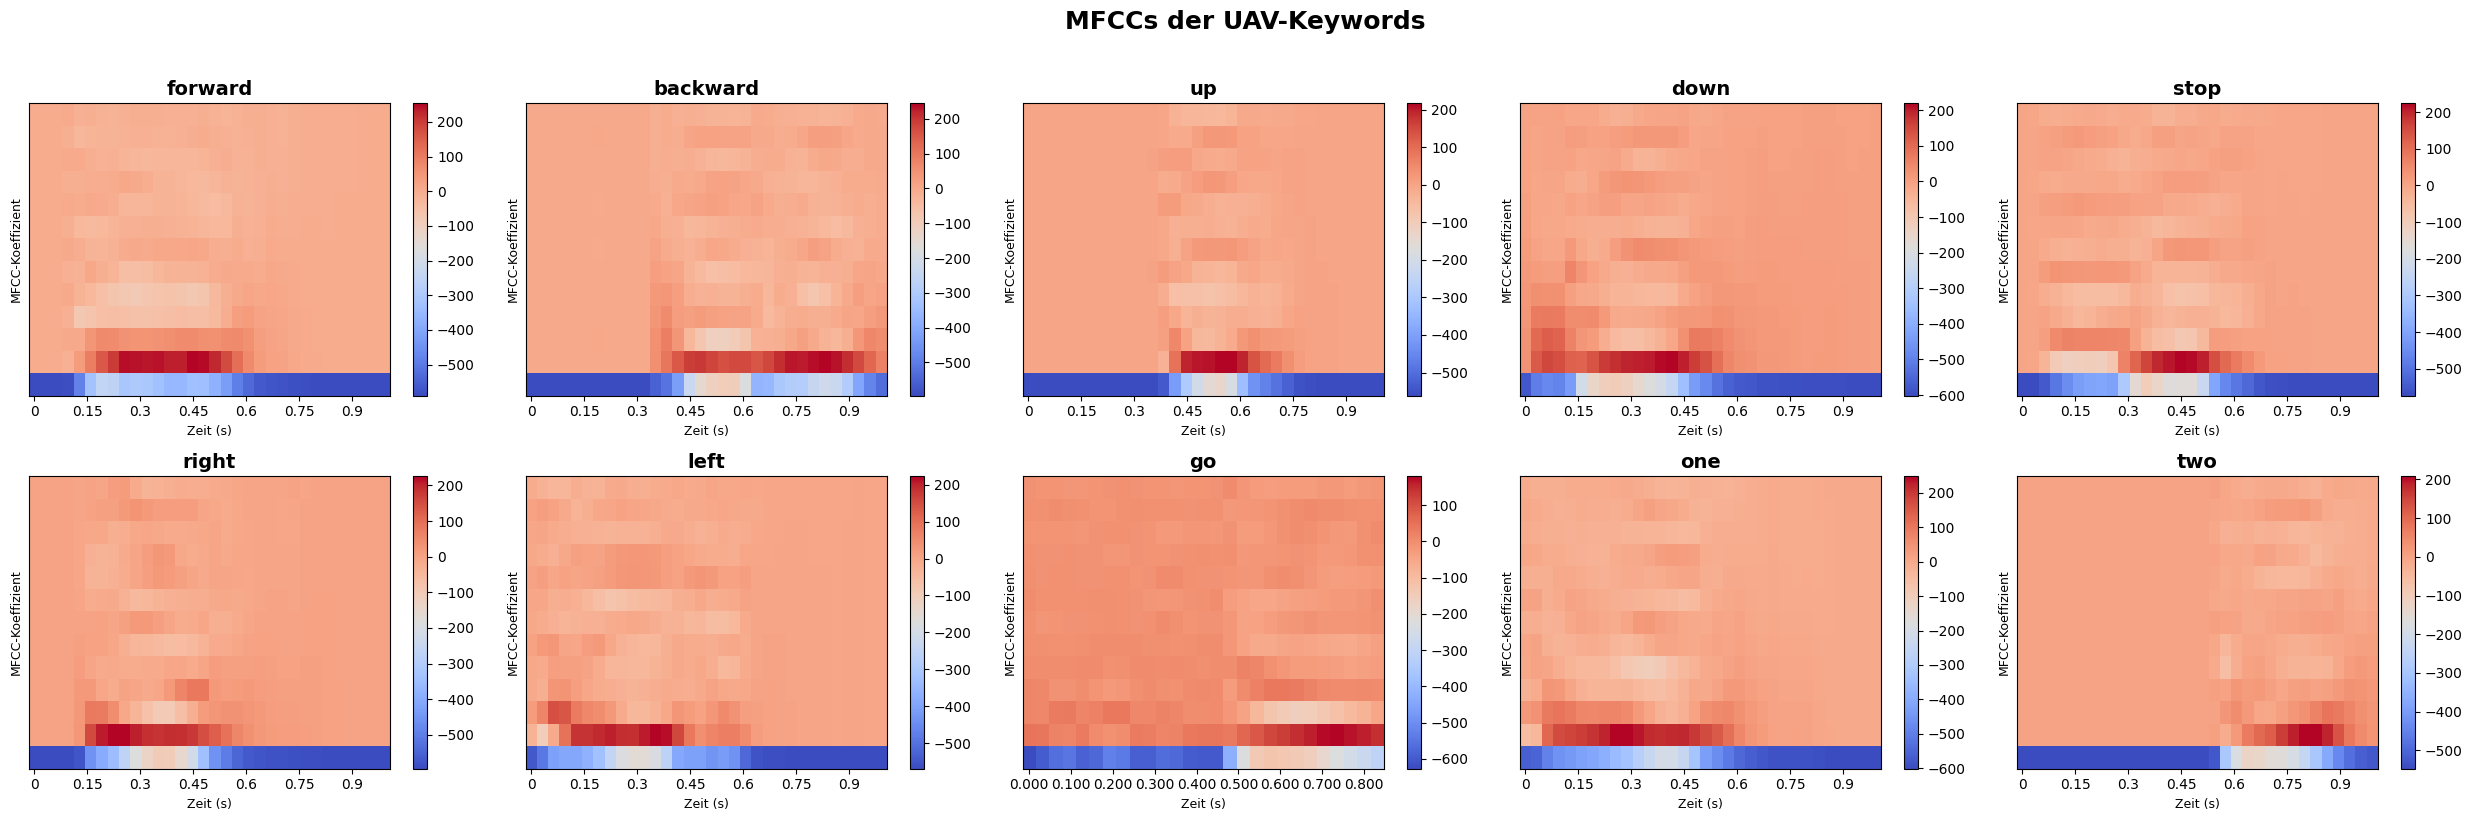

In [13]:
key_words = ['forward', 'backward', 'up', 'down', 'stop', 'right', 'left', 'go', 'one', 'two']

cols = 5
rows = 2
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()

for i, keyword in enumerate(key_words):
    keyword_path = Path(path_to_raw_data) / keyword
    example_file = list(keyword_path.glob('*.wav'))[0]

    audio, sr = librosa.load(example_file, sr=None)
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)

    img = librosa.display.specshow(mfccs, x_axis='time', sr=sr, ax=axes[i])
    axes[i].set_title(keyword, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Zeit (s)', fontsize=9)
    axes[i].set_ylabel('MFCC-Koeffizient', fontsize=9)
    fig.colorbar(img, ax=axes[i])

plt.suptitle('MFCCs der UAV-Keywords', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 9. Energie- & Stille-Analyse

Einige Dateien könnten trotz korrekter Länge kaum nutzbaren Inhalt haben — z.B. sehr leise Aufnahmen oder reine Stille.  
Solche Ausreißer können das Training negativ beeinflussen.

Analysiert werden zwei Maße:
- **RMS Energy** (Root Mean Square): mittlere Signalenergie — niedriger Wert = leise/Stille
- **Zero-Crossing Rate (ZCR)**: wie oft wechselt das Signal das Vorzeichen — hoher Wert = viel Rauschen, sehr tiefer Wert = Stille

Es werden nur die **10 Keywords** analysiert, da diese direkt für das Training relevant sind.


/var/folders/bm/ppjrcfbj1cq9d4027j3_39t80000gn/T/ipykernel_4132/3526460394.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(rms_per_class.values(), labels=rms_per_class.keys(), vert=True)
/var/folders/bm/ppjrcfbj1cq9d4027j3_39t80000gn/T/ipykernel_4132/3526460394.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(zcr_per_class.values(), labels=zcr_per_class.keys(), vert=True)


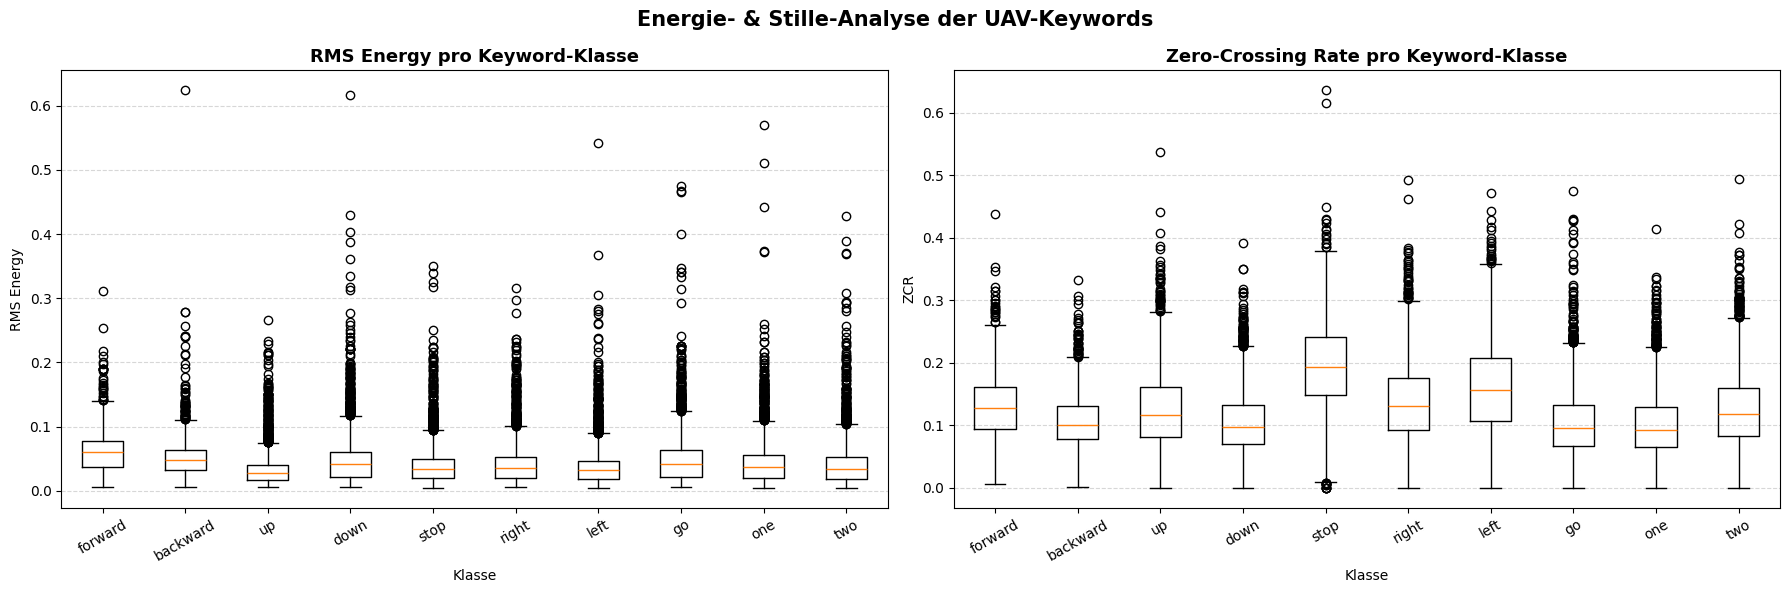


Dateien mit sehr niedriger RMS Energy (< 0.01) — potenzielle Stille-Ausreißer:
  [forward] 62ccd358_nohash_0.wav  RMS=0.0056
  [forward] 3d9bbe2d_nohash_1.wav  RMS=0.0062
  [forward] 62f05757_nohash_1.wav  RMS=0.0064
  [forward] 1fc04a13_nohash_5.wav  RMS=0.0069
  [forward] e49428d9_nohash_1.wav  RMS=0.0079
  [forward] 58137b8e_nohash_0.wav  RMS=0.0076
  [forward] 1fc04a13_nohash_4.wav  RMS=0.0069
  [forward] 62f05757_nohash_0.wav  RMS=0.0088
  [forward] 3d9bbe2d_nohash_0.wav  RMS=0.0079
  [forward] 1b18600d_nohash_1.wav  RMS=0.0092
  [forward] 26c54f73_nohash_0.wav  RMS=0.0094
  [forward] 3d9bbe2d_nohash_2.wav  RMS=0.0095
  [forward] e49428d9_nohash_2.wav  RMS=0.0086
  [forward] d0745d72_nohash_0.wav  RMS=0.0094
  [forward] 62f05757_nohash_3.wav  RMS=0.0086
  [forward] 1b18600d_nohash_2.wav  RMS=0.0093
  [forward] 1fc04a13_nohash_3.wav  RMS=0.0089
  [forward] 964c7c9e_nohash_0.wav  RMS=0.0085
  [forward] 1fc04a13_nohash_2.wav  RMS=0.0076
  [forward] 70880cc6_nohash_0.wav  RMS=0.0088


In [14]:
key_words = ['forward', 'backward', 'up', 'down', 'stop', 'right', 'left', 'go', 'one', 'two']

rms_per_class = {}
zcr_per_class = {}

for keyword in key_words:
    keyword_path = Path(path_to_raw_data) / keyword
    rms_values = []
    zcr_values = []
    for file in keyword_path.glob('*.wav'):
        audio, sr = librosa.load(file, sr=None)
        rms_values.append(np.mean(librosa.feature.rms(y=audio)))
        zcr_values.append(np.mean(librosa.feature.zero_crossing_rate(y=audio)))
    rms_per_class[keyword] = rms_values
    zcr_per_class[keyword] = zcr_values

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].boxplot(rms_per_class.values(), labels=rms_per_class.keys(), vert=True)
axes[0].set_title('RMS Energy pro Keyword-Klasse', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Klasse')
axes[0].set_ylabel('RMS Energy')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

axes[1].boxplot(zcr_per_class.values(), labels=zcr_per_class.keys(), vert=True)
axes[1].set_title('Zero-Crossing Rate pro Keyword-Klasse', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Klasse')
axes[1].set_ylabel('ZCR')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Energie- & Stille-Analyse der UAV-Keywords', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Ausreißer: Dateien mit sehr niedriger RMS (< 0.01) ────────────────────
print('\nDateien mit sehr niedriger RMS Energy (< 0.01) — potenzielle Stille-Ausreißer:')
found = False
for keyword in key_words:
    keyword_path = Path(path_to_raw_data) / keyword
    for file in keyword_path.glob('*.wav'):
        audio, sr = librosa.load(file, sr=None)
        rms = np.mean(librosa.feature.rms(y=audio))
        if rms < 0.01:
            print(f'  [{keyword}] {file.name}  RMS={rms:.4f}')
            found = True
if not found:
    print('  Keine Ausreißer gefunden.')
